In [1]:
import tensorflow as tf
from tensorflow.keras.layers import (
    Input, Embedding, Dense, Attention, Concatenate, RNN, GRUCell
)
from tensorflow.keras.models import Model
import numpy as np

# ----------------------------
# Data
# ----------------------------
vocab_size = 50
maxlen = 5
samples = 1000

X = np.random.randint(1, vocab_size, (samples, maxlen))
y = np.roll(X, -1, axis=1)

In [2]:
# ----------------------------
# Encoder
# ----------------------------
enc_in = Input(shape=(maxlen,))
enc_emb = Embedding(vocab_size, 32)(enc_in)

encoder = RNN(
    GRUCell(64),
    return_sequences=True,
    return_state=True
)
enc_out, enc_state = encoder(enc_emb)

# ----------------------------
# Decoder
# ----------------------------
dec_in = Input(shape=(maxlen,))
dec_emb = Embedding(vocab_size, 32)(dec_in)

decoder = RNN(
    GRUCell(64),
    return_sequences=True
)
dec_out = decoder(dec_emb, initial_state=[enc_state])

# ----------------------------
# Attention
# ----------------------------
attn = Attention()([dec_out, enc_out])
combined = Concatenate()([dec_out, attn])

# ----------------------------
# Output
# ----------------------------
out = Dense(vocab_size, activation="softmax")(combined)

model = Model([enc_in, dec_in], out)

In [3]:
model.summary()

Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer         │ (None, 5)         │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ input_layer_1       │ (None, 5)         │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ embedding           │ (None, 5, 32)     │      1,600 │ input_layer[0][0] │
│ (Embedding)         │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ embedding_1         │ (None, 5, 32)     │      1,600 │ input_layer_1[0]… │
│ (Embedding)         │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ rnn (RNN)           │ [(None, 5, 64),   │     18,816 │ embedding[0][0]   │
│                     │ (None, 64)]       │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ rnn_1 (RNN)         │ (None, 5, 64)     │     18,816 │ embedding_1[0][0… │
│                     │                   │            │ rnn[0][1]         │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ attention           │ (None, 5, 64)     │          0 │ rnn_1[0][0],      │
│ (Attention)         │                   │            │ rnn[0][0]         │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ concatenate         │ (None, 5, 128)    │          0 │ rnn_1[0][0],      │
│ (Concatenate)       │                   │            │ attention[0][0]   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense (Dense)       │ (None, 5, 50)     │      6,450 │ concatenate[0][0] │
└─────────────────────┴───────────────────┴────────────┴───────────────────┘

 Total params: 47,282 (184.70 KB)

 Trainable params: 47,282 (184.70 KB)

 Non-trainable params: 0 (0.00 B)

In [4]:
model.compile(
    optimizer="adam",
    loss="sparse_categorical_crossentropy",
    run_eagerly=True,
    metrics=["accuracy"]
)

In [5]:
hist = model.fit([X, X], y[..., None], epochs=100, batch_size=64)

Epoch 1/100
16/16 ━━━━━━━━━━━━━━━━━━━━ 7s 198ms/step - accuracy: 0.0233 - loss: 3.9100
Epoch 2/100
16/16 ━━━━━━━━━━━━━━━━━━━━ 4s 240ms/step - accuracy: 0.0643 - loss: 3.8932
Epoch 3/100
16/16 ━━━━━━━━━━━━━━━━━━━━ 3s 193ms/step - accuracy: 0.0584 - loss: 3.8673
Epoch 4/100
16/16 ━━━━━━━━━━━━━━━━━━━━ 3s 198ms/step - accuracy: 0.0601 - loss: 3.8127
Epoch 5/100
16/16 ━━━━━━━━━━━━━━━━━━━━ 3s 209ms/step - accuracy: 0.0837 - loss: 3.6660
Epoch 6/100
16/16 ━━━━━━━━━━━━━━━━━━━━ 4s 218ms/step - accuracy: 0.1321 - loss: 3.4363
Epoch 7/100
16/16 ━━━━━━━━━━━━━━━━━━━━ 3s 195ms/step - accuracy: 0.1571 - loss: 3.2239
Epoch 8/100
16/16 ━━━━━━━━━━━━━━━━━━━━ 3s 199ms/step - accuracy: 0.1767 - loss: 3.0908
Epoch 9/100
16/16 ━━━━━━━━━━━━━━━━━━━━ 4s 234ms/step - accuracy: 0.1793 - loss: 2.9734
Epoch 10/100
16/16 ━━━━━━━━━━━━━━━━━━━━ 3s 196ms/step - accuracy: 0.1937 - loss: 2.8596
Epoch 11/100
16/16 ━━━━━━━━━━━━━━━━━━━━ 3s 215ms/step - accuracy: 0.2087 - loss: 2.7785
Epoch 12/100
16/16 ━━━━━━━━━━━━━━━━━━━━ 3

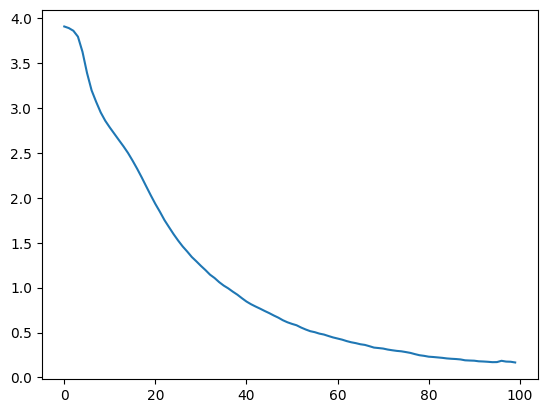

In [7]:
import matplotlib.pyplot as plt
plt.plot(hist.history['loss'])
plt.show()

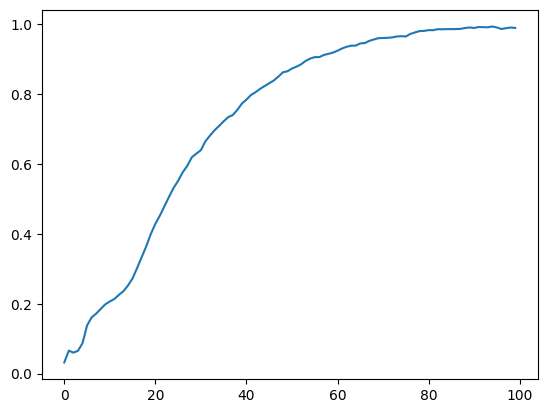

In [8]:
plt.plot(hist.history['accuracy'])
plt.show()